# Lamina Tubulin Phasor Workflow

Calibrate channel timing, compute corrected phasor maps, and visualize lifetime maps.


In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
from brighteyes_mcs_file import Alignment, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts
import brighteyes_flim.graph_tools as graph


## Calibration Parameters


In [4]:
FILE_REFERENCE = '/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-50-34.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47.h5'
DATA_KEY = ("data", "data_channels_extra")
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]

TAU_REF = None
REFERENCE_TYPE = 'irf'
FIT_MODE = "model_shift"
FIT_TYPE = "likelihood"
LASER_FREQ_MHZ = 41.48
LASER_PERIOD_NS = 1e3 / LASER_FREQ_MHZ
CHANNEL_SKEW_SOURCE = 'irf'
OVERWRITE = True

FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    clean_irf=True,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)


Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/home/mdonato/myDev/BrightEyes-MCS-File/src/brighteyes_mcs_file/h5_data_calibrator.py:1436: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()


/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47_calib.h5


## Load Calibrated Data And Compute Phasors


In [5]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf["calibration/data"]
    configuration = hf["configurationGUI"]

    laser_freq_mhz = float(calibration.attrs["laser_freq_in_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_in_ns"])
    nbin = int(configuration.attrs["timebin_per_pixel"])
    pixel_size_x_um = float(configuration.attrs["range_x"]) / float(configuration.attrs["nx"])
    pxdwelltime = float(configuration.attrs["time_resolution"]) * nbin

    data_input = hf["data"][:]
    channel_skew = calibration["channel_skew"][:]
    irf_common_delay_realigned = calibration["irf_common_delay_realigned"][:]

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment = np.sum(irf_common_delay_realigned, axis=-1)

data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)

h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)


Summing shifted histograms:   0%|          | 0/1562500 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1562500 [00:00<?, ?it/s]

Summing shifted histograms:   0%|          | 0/1 [00:00<?, ?it/s]

Using calibrated laser timing: 41.4800 MHz (24.1080 ns)
data_summed: (1250, 1250, 81)
irf_summed: (81,)
phasor map: (1250, 1250)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

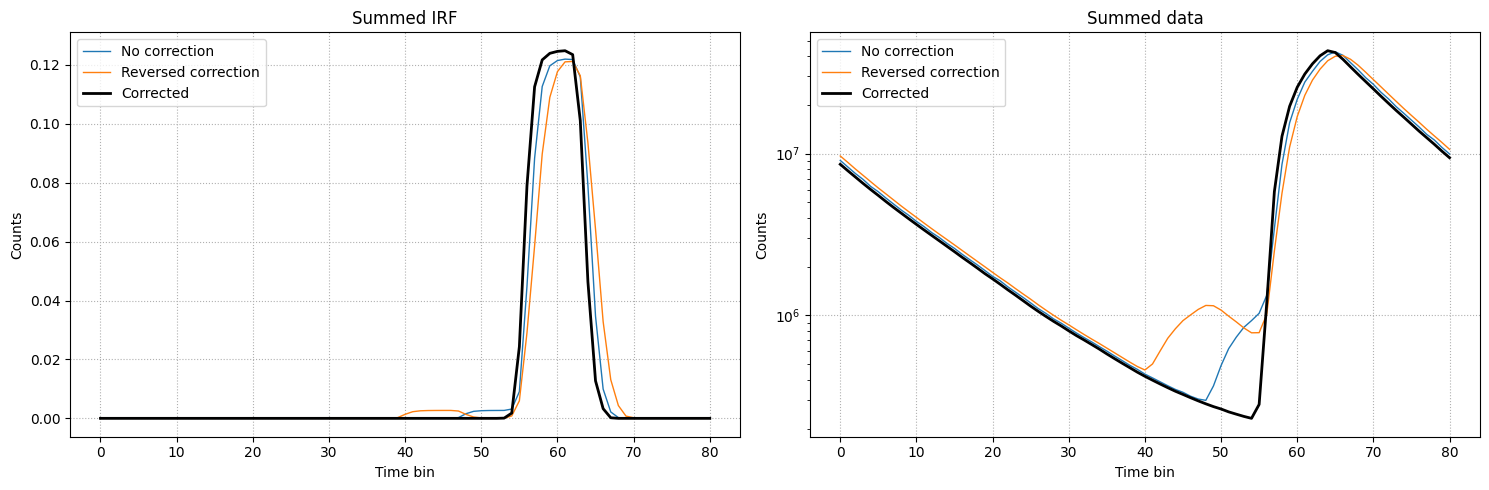

In [6]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Correct Phasors And Build Lifetime Maps


In [7]:
intensity_map = data_summed.sum(axis=-1)

if 'phase_only' == "phase_only":
    irf_correction = irf_phasor / abs(irf_phasor)
else:
    irf_correction = irf_phasor

phasor_map = h5_dataset_phasor_pix / irf_correction
tau_m_map = flim.calculate_tau_m(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map

threshold = 0.05
thresholded_phasor_map = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map,
    intensity=intensity_map,
    threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)


IRF phasor: (-0.07294519451703246-0.9786453074509041j)
thresholded pixels: 1536787


Text(0.5, 1.0, 'Corrected phasor distribution')

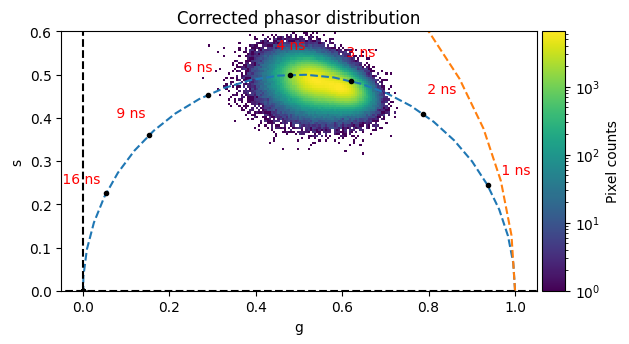

In [8]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")


## Lifetime Visualization


/home/mdonato/.local/share/mamba/envs/venv-3.12/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

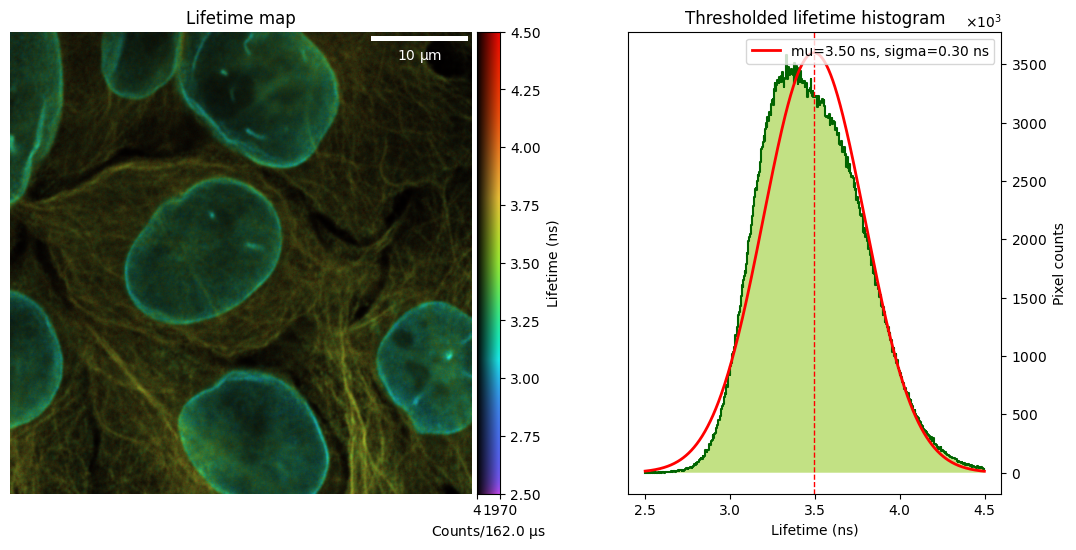

In [9]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[2.5, 4.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

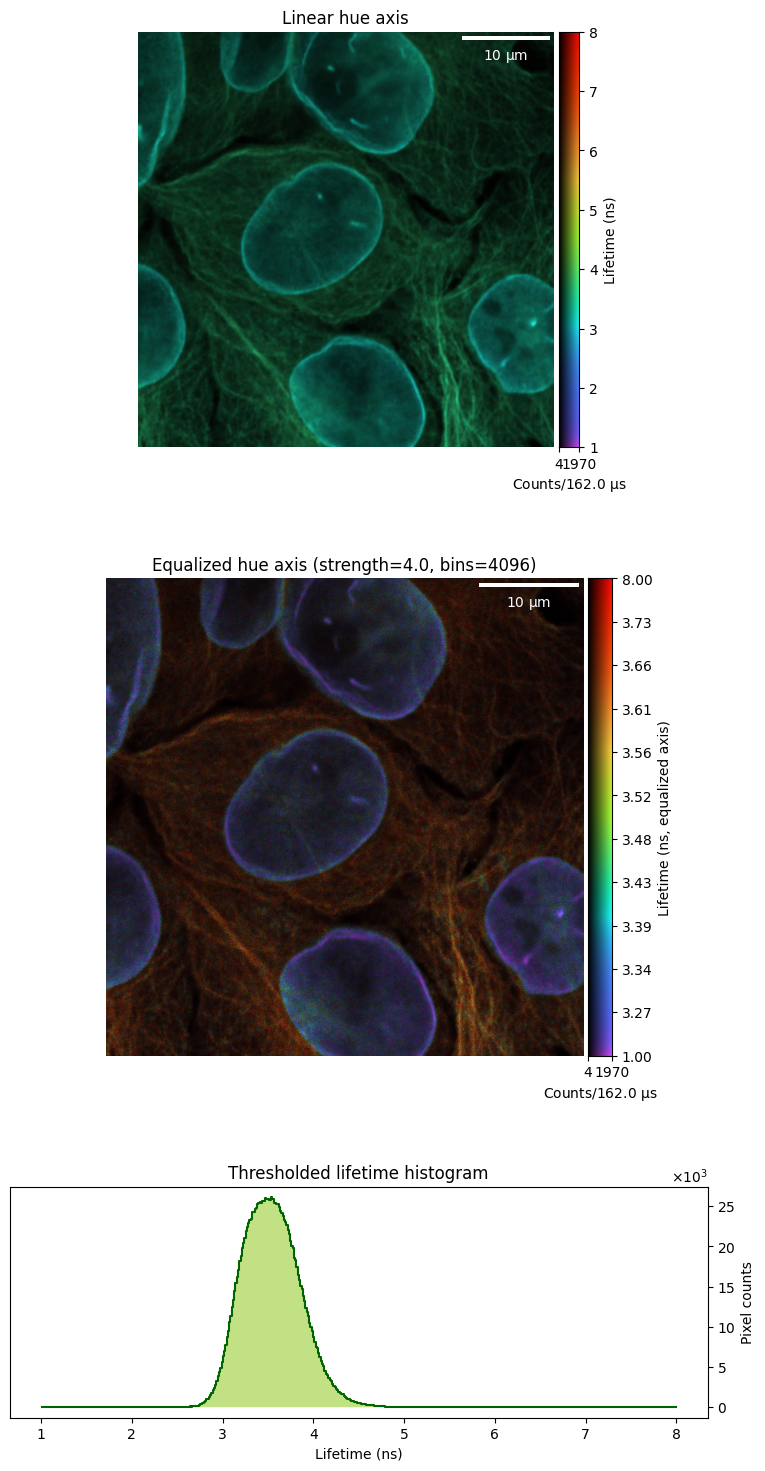

In [10]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 8.0],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


In [11]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)
